In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import config

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [ ]:
import random, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [6]:
random.seed(42)

### Encoder

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_height, input_width, hidden_dim_1, hidden_dim_2, latent_dim):
        super().__init__()
        self.input_dim = input_height * input_width
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden_dim_1),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.LeakyReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim_2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim_2, latent_dim)
        
    def forward(self, x):
        h = self.net(x) # TODO: i dont understand the syntax here
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar       

### Decoder

In [35]:
class Decoder(nn.Module):
    def __init__(self, output_height, output_width, hidden_dim_1, hidden_dim_2, latent_dim):
        super().__init__()
        self.output_dim = output_height * output_width
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim_2),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_1),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_1, self.output_dim),
            # nn.Sigmoid(), # because spectrograms are normalized to 0-1
            nn.Unflatten(1, (output_height, output_width))
        )
        
    def forward(self, z):
        return self.net(z)

### Vanilla/Basic VAE

In [36]:
class VanillaVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.encoder = Encoder(
            input_height=cfg.INPUT_HEIGHT,
            input_width=cfg.INPUT_WIDTH,
            hidden_dim_1=cfg.HIDDEN_DIM_1,
            hidden_dim_2=cfg.HIDDEN_DIM_2,
            latent_dim=cfg.LATENT_DIM
        )
        self.decoder = Decoder(
            output_height=cfg.INPUT_HEIGHT,
            output_width=cfg.INPUT_WIDTH,
            hidden_dim_1=cfg.HIDDEN_DIM_1,
            hidden_dim_2=cfg.HIDDEN_DIM_2,
            latent_dim=cfg.LATENT_DIM
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
      x_recon = self.decoder(z)
      return x_recon.view(-1, 1, self.config.INPUT_HEIGHT, self.config.INPUT_WIDTH)
  
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### Dataset Class

In [45]:
class AudioSpectrogramDataset(Dataset):
    def __init__(self, dataset_dir, expected_shape=(config.INPUT_HEIGHT, config.INPUT_WIDTH), add_channel_dim=False):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.file_paths = sorted(self.dataset_dir.rglob("*npy"))
        self.expected_shape = expected_shape
        self.add_channel_dim = add_channel_dim
        self.global_min = -80.0
        self.global_max = 0.0
        
        # mins, maxs = [], []
        # for fp in self.file_paths[:200]:
        #     x = np.load(fp)
        #     mins.append(x.min())
        #     maxs.append(x.max())

        # print("min of mins:", min(mins))
        # print("max of maxs:", max(maxs))
        # print("avg min:", sum(mins)/len(mins))
        # print("avg max:", sum(maxs)/len(maxs))
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        x = np.load(file_path)
        x = (x - self.global_min) / (self.global_max - self.global_min)
        # x = np.clip(x, 0.0, 1.0)
        x = torch.tensor(x, dtype=torch.float32)
        if self.add_channel_dim: x = x.unsqueeze(0)
        
        return x, str(file_path)

## Activating GPU

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
device

device(type='cuda')

## Train and Test Data Preparation

In [28]:
npy_dir = Path("../..") / config.FEATURES_DIR

In [46]:
dataset = AudioSpectrogramDataset(dataset_dir=npy_dir)

In [47]:
BATCH_SIZE = 32

In [31]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [48]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [49]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=config.SHUFFLE)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [50]:
len(train_dataset), len(test_dataset)

(800, 200)

## Training and Evaluating

In [51]:
def vae_loss(x_hat, x, beta, mu, logvar, epoch): # required for evaluation
    # recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    beta = min(1.0, epoch / 10)
    total = recon + beta * kl # TODO: use beta when and why?
    
    return total, recon, kl

In [52]:
def train_one_epoch(model, loader, optimizer, beta, epoch, device=device):
    model.train()
    total_sum = recon_sum = kl_sum = n = 0
    
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n += x.size(0) # TODO: = 1 because channel?  
              
    train_total = total_sum / max(n, 1)
    train_recon = recon_sum / max(n, 1)
    train_kl = kl_sum / max(n, 1)
    
    return {
        "loss": train_total,
        "recon": train_recon,
        "kl": train_kl
    }

In [53]:
def evaluate(model, loader, beta, epoch, device=device):
    model.eval()
    total_sum = recon_sum = kl_sum = n = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
            
            total_sum += loss.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += x.size(0)

    test_total = total_sum / max(n, 1)
    test_recon = recon_sum / max(n, 1)
    test_kl = kl_sum / max(n, 1)
    
    return {
        "loss": test_total,
        "recon": test_recon,
        "kl": test_kl
    }

In [54]:
def train_vae(model, train_loader, test_loader, optimizer, beta, device=device):
    history = {"train_total": [], "test_total": [],
               "train_recon": [], "test_recon": [],
               "train_kl": [], "test_kl": []}
    for epoch in range(config.EPOCHS):
        train_stats = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, beta=beta, epoch=epoch, device=device)
        test_stats = evaluate(model=model, loader=test_loader, beta=beta, epoch=epoch, device=device)
        train_total = train_stats["loss"]
        test_total = test_stats["loss"]
        train_recon = train_stats["recon"]
        test_recon = test_stats["recon"]
        train_kl = train_stats["kl"]
        test_kl = test_stats["kl"]
        history["train_total"].append(train_total)
        history["test_total"].append(test_total)
        history["train_recon"].append(train_recon)
        history["test_recon"].append(test_recon)
        history["train_kl"].append(train_kl)
        history["test_kl"].append(test_kl)
        print(
            f"epoch {epoch:02d} | "
            f"train_total={train_total:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | "
            f"test_total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f}"
        )
        
    return history

In [24]:
def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_total"], label="train total")
    plt.plot(history["test_total"], label="test total")
    plt.plot(history["train_recon"], label="train recon")
    plt.plot(history["test_recon"], label="test recon")
    plt.plot(history["train_kl"], label="train kl")
    plt.plot(history["test_kl"], label="test kl")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Single Iteration Model

In [62]:
model = VanillaVAE(cfg=config).to(device)

In [63]:
model

VanillaVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=5824, out_features=512, bias=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Linear(in_features=512, out_features=128, bias=True)
      (4): LeakyReLU(negative_slope=0.01)
    )
    (mu_layer): Linear(in_features=128, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=512, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=512, out_features=5824, bias=True)
      (5): Unflatten(dim=1, unflattened_size=(64, 91))
    )
  )
)

In [65]:
optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [66]:
history = train_vae(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, beta=50.0, device=device)

epoch 00 | train_total=42.1039 recon=42.1039 kl=1.3510 | test_total=18.9654 recon=18.9654 kl=2.7964
epoch 01 | train_total=8.5119 recon=8.2632 kl=2.4868 | test_total=4.7519 recon=4.4775 kl=2.7435
epoch 02 | train_total=3.9112 recon=3.4208 kl=2.4519 | test_total=3.8028 recon=3.2559 kl=2.7343
epoch 03 | train_total=3.6236 recon=2.9195 kl=2.3470 | test_total=3.7999 recon=3.0661 kl=2.4457
epoch 04 | train_total=3.6560 recon=2.8446 kl=2.0286 | test_total=3.8811 recon=3.0682 kl=2.0323
epoch 05 | train_total=3.7206 recon=2.8723 kl=1.6967 | test_total=3.9792 recon=3.1271 kl=1.7042
epoch 06 | train_total=3.7733 recon=2.9106 kl=1.4379 | test_total=4.0274 recon=3.1200 kl=1.5124
epoch 07 | train_total=3.8145 recon=2.9426 kl=1.2455 | test_total=4.0885 recon=3.1881 kl=1.2864
epoch 08 | train_total=3.8785 recon=2.9955 kl=1.1037 | test_total=4.1927 recon=3.2509 kl=1.1772
epoch 09 | train_total=3.9031 recon=3.0031 kl=0.9999 | test_total=4.2447 recon=3.3047 kl=1.0445
epoch 10 | train_total=3.9422 recon=

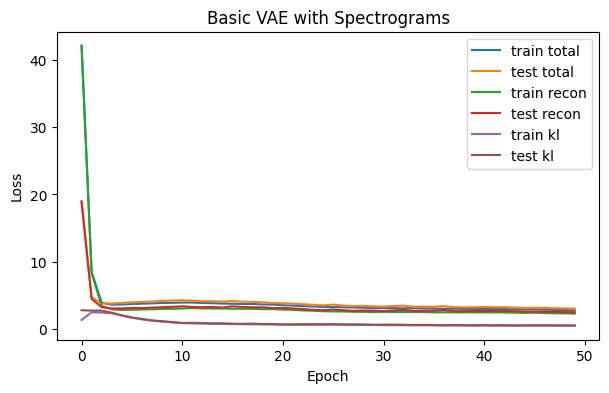

In [67]:
plot_history(history, "Basic VAE with Spectrograms")

## Extract Latent Features

In [60]:
def show_reconstructions(model, dataset, n=10, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    
    with torch.no_grad():
        for i in range(n):
            # Get a real sample
            print(dataset[i][1])
            x = dataset[i][0].unsqueeze(0).to(device)
            x_hat, _, _ = model(x)
            
            # Original Spectrogram
            img_org = x.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_org, origin='lower', aspect='auto')
            axes[i, 0].set_title(f"Original {i}")
            
            # Reconstructed Spectrogram
            img_recon = x_hat.squeeze().cpu().numpy()
            axes[i, 1].imshow(img_recon, origin='lower', aspect='auto')
            axes[i, 1].set_title(f"Reconstructed {i}")
            
    plt.tight_layout()
    plt.show()

..\..\data\features\MT0001298241_clip_8.npy
..\..\data\features\MT0003909575_clip_7.npy


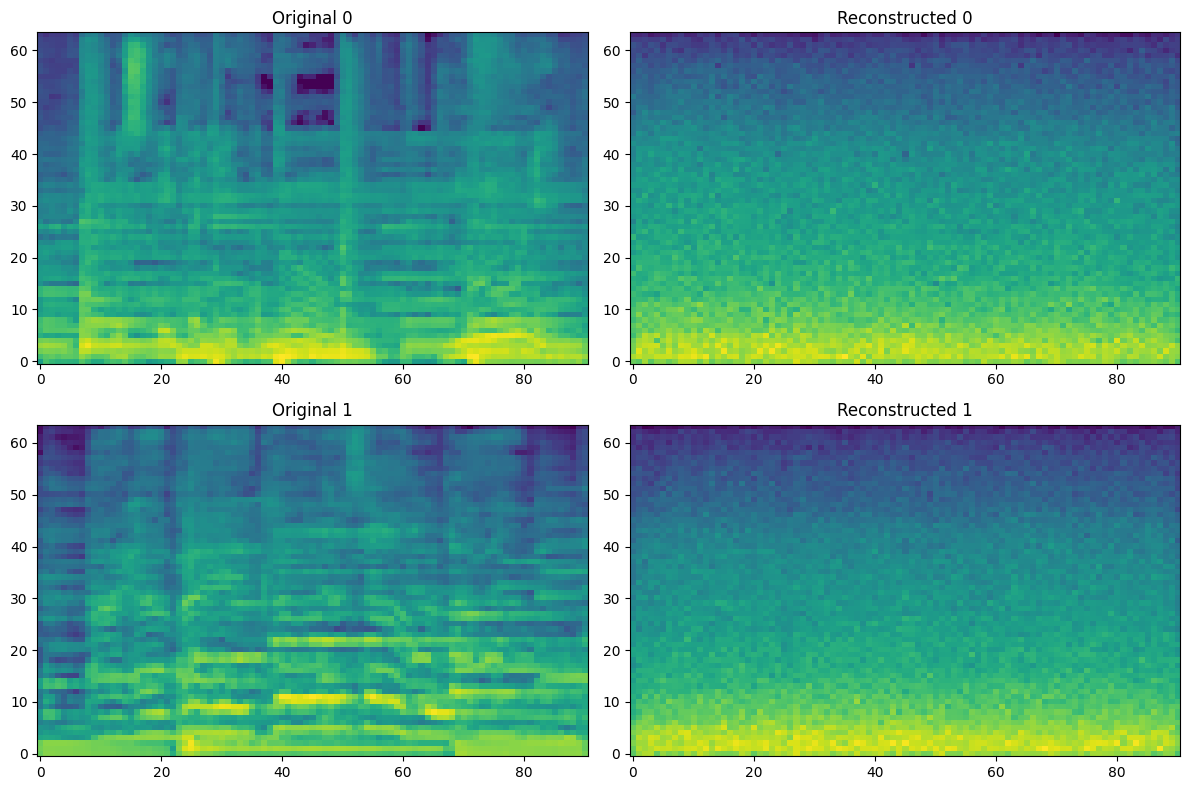

In [68]:
show_reconstructions(model=model, dataset=train_dataset, n=2)

In [84]:
def extract_latents(model, loader, device=device):
    model.eval()
    latents = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            latents.append(mu.cpu().numpy())
            
    return np.concatenate(latents)

In [82]:
latent_vecs = extract_latents(model=model, loader=train_loader)

In [83]:
latent_vecs

array([[-0.04771413,  0.1631144 , -0.20757312, ..., -0.01013273,
         0.05448157, -0.51610124],
       [-0.3956494 , -0.02154915,  0.07215863, ..., -0.39225543,
        -0.00759634, -0.54428947],
       [-0.06434794,  0.20781532, -0.20459312, ..., -0.04051578,
         0.07482025, -0.53722143],
       ...,
       [-0.06698076,  0.18979794, -0.16436827, ..., -0.04475206,
         0.14532712, -0.50627726],
       [-0.20267315, -0.0436298 ,  0.01446813, ..., -0.20465672,
         0.13847727, -0.5762305 ],
       [-0.1720189 ,  0.36697546, -0.28417933, ..., -0.13435894,
        -0.0730685 , -0.49142146]], shape=(800, 32), dtype=float32)